# State Representations

The choice of state representation determines which solver YAQS uses and how
large a system you can study. Matrix product states keep large simulations
manageable when entanglement remains limited. Dense vectors and density matrices
provide useful small-system references, with different costs for noisy dynamics.

Choose the representation when constructing a {class}`~mqt.yaqs.State`. YAQS
selects the solver from that choice; it does not switch representations when the
calculation becomes expensive.

## Choose a representation and solver

| `State` representation | Analog solver                            | When to use it                                                                 |
| ---------------------- | ---------------------------------------- | ------------------------------------------------------------------------------ |
| `"mps"` (default)      | Tensor jump method (TJM).                | Large chains with manageable entanglement, and circuit simulation.             |
| `"vector"`             | Monte Carlo wave-function method (MCWF). | Small systems where you want pure-state trajectories without MPS compression.  |
| `"density_matrix"`     | Lindblad master equation.                | Small open systems, mixed initial states, and deterministic ensemble averages. |

For presets, use `State(length, initial="zeros", representation="vector")`, for
example. Supplying `vector=`, `density_matrix=`, or `tensors=` selects the
matching representation automatically. See {doc}`state_initialization` for state
preparation and local dimensions.

With noise, TJM and MCWF evolve independent pure-state trajectories and average
their observables. Lindblad evolution propagates the ensemble density matrix
directly. Without noise, the trajectory solvers evolve a single pure state;
Lindblad evolution still carries a density matrix.

## How state storage scales

Let $L$ be the number of sites, $d$ their common local dimension, and $D=d^L$
the full Hilbert-space dimension. For qubits, $d=2$. An MPS stores local tensors
joined by bonds; the maximum bond dimension $\chi$ controls how much
entanglement it can represent.

| Representation | Complex numbers in one state | For qubits                           |
| -------------- | ---------------------------- | ------------------------------------ |
| MPS            | $O(Ld\chi^2)$.               | Linear in $L$ if $\chi$ stays fixed. |
| Vector         | $D$.                         | $2^L$.                               |
| Density matrix | $D^2$.                       | $4^L$.                               |

Each additional qubit doubles vector storage and quadruples density-matrix
storage. Increasing an MPS bond dimension by a factor of two can increase its
state storage by about four. For strongly entangled states, the bond dimension
needed for an accurate MPS can itself grow exponentially with system size;
linear scaling at fixed bond dimension is not a guarantee for every physical
problem. See the
[TJM publication](https://www.nature.com/articles/s41467-025-66846-x) for the
trajectory formulation.

The figure counts `complex128` state arrays, at 16 bytes per entry. The MPS
curves use bond caps of 16 and 64, with each bond also limited by the dimensions
of the two subsystems it separates. These are calculated storage estimates; no
large states are allocated.

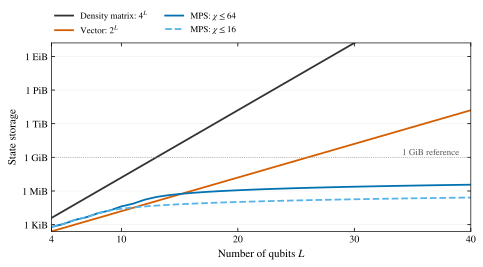

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.linewidth": 0.7,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "lines.linewidth": 1.8,
    "figure.constrained_layout.use": True,
    "savefig.dpi": 180,
})

qubits = np.arange(4, 41)
vector_bytes = 16 * 2.0**qubits
density_bytes = 16 * 4.0**qubits
mps_bytes = {}
for cap in (16, 64):
    sizes = []
    for sites in qubits:
        bonds = [min(cap, 2**min(cut, sites - cut)) for cut in range(sites + 1)]
        sizes.append(16 * sum(2 * left * right for left, right in zip(bonds[:-1], bonds[1:], strict=True)))
    mps_bytes[cap] = np.array(sizes)

fig, ax = plt.subplots(figsize=(6.6, 3.6))
ax.semilogy(qubits, density_bytes, color="0.2", label=r"Density matrix: $4^L$")
ax.semilogy(qubits, vector_bytes, color="#D55E00", label=r"Vector: $2^L$")
ax.semilogy(qubits, mps_bytes[64], color="#0072B2", label=r"MPS: $\chi\leq64$")
ax.semilogy(qubits, mps_bytes[16], "--", color="#56B4E9", label=r"MPS: $\chi\leq16$")
ax.axhline(2.0**30, color="0.6", linewidth=0.8, linestyle=":")
ax.text(39, 2.0**30 * 1.6, "1 GiB reference", ha="right", fontsize=9, color="0.35")
ax.set(xlabel=r"Number of qubits $L$", ylabel="State storage", xlim=(4, 40), ylim=(2.0**8, 2.0**64))
ax.set_xticks([4, 10, 20, 30, 40])
ax.set_yticks([2.0**10, 2.0**20, 2.0**30, 2.0**40, 2.0**50, 2.0**60],
              labels=["1 KiB", "1 MiB", "1 GiB", "1 TiB", "1 PiB", "1 EiB"])
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.02), ncols=2, borderaxespad=0)
ax.grid(axis="y", alpha=0.15)
plt.show()

The plot shows one state's arrays, not peak solver memory or a practical qubit
limit. The density-matrix curve continues above the plotted range. Hamiltonians,
jump operators, temporary arrays, worker copies, and saved observable
trajectories also use memory. In particular, a cached propagator can be much
larger than the state it evolves.

## How solver work scales

For an MPS with fixed local dimension, Hamiltonian MPO bond dimension, and local
solver effort, a TDVP sweep costs roughly $O(L\chi^3)$. The MPO bond dimension
measures the size of the Hamiltonian's tensor-network representation. More
complex interactions and growing state bonds increase the work. This estimate
describes local TDVP sweeps, not every supported integrator or noise pattern.

Dense solvers have two regimes in the current implementation:

| Solver                    | Small-system method                                                                                                                  | Method above the cache threshold                                                                            |
| ------------------------- | ------------------------------------------------------------------------------------------------------------------------------------ | ----------------------------------------------------------------------------------------------------------- |
| Vector / MCWF             | Build a dense $D\times D$ step propagator: roughly $O(D^3)$ setup, $O(D^2)$ storage and work per step.                               | Apply the exponential through sparse Krylov methods; work depends on operator nonzeros and iteration count. |
| Density matrix / Lindblad | Build a dense $D^2\times D^2$ generator and step propagator: roughly $O(D^6)$ exponential setup, $O(D^4)$ storage and work per step. | Integrate the matrix master equation with adaptive RK45, without storing the full generator.                |

For a fixed number of Krylov iterations and short-range sparse operators, vector
evolution typically needs order $LD$ work per exponential action. For a
Hamiltonian with order $LD$ nonzeros and $K$ local jump channels, one Lindblad
derivative evaluation costs order $(L+K)D^2$. The number of adaptive steps
depends on the dynamics and tolerances, so these estimates do not give a single
runtime law for every problem.

:::{dropdown} Propagator thresholds and other memory costs
The vector solver caches its dense step propagator when `D <= 4096` (up to 12
qubits). The density-matrix solver builds a dense generator and caches its step
propagator when `D**2 <= 4096` (up to 6 qubits). At either upper threshold, one
propagator alone occupies 256 MiB in `complex128`; preprocessing needs
additional arrays. These are implementation thresholds, not recommended system
sizes or user memory limits.

MPS evolution also stores the Hamiltonian MPO and contraction environments. For
uniform dimensions and an MPO bond dimension $w$, their typical storage is
$O(Ld^2w^2)$ and $O(Lw\chi^2)$, respectively. Intermediate bonds can exceed the
final retained bonds during an update.

For unequal local dimensions, replace $D=d^L$ with $D=\prod_i d_i$. The exact
MPS state entry count is $\sum_i d_i\chi_i\chi_{i+1}$, where the end bonds have
dimension one. Local dimensions above two can raise costs sharply even when the
number of sites stays fixed.
:::

### Trajectories, time steps, and parallelism

Noisy TJM and MCWF work grows approximately in proportion to `num_traj` and the
number of evolution steps, at fixed numerical settings. Standard Monte Carlo
error decreases as $1/\sqrt{N_{\mathrm{traj}}}$: halving that error generally
requires four times as many trajectories. Increasing the trajectory count does
not remove timestep or MPS approximation errors.

Lindblad evolution needs one deterministic run, so increasing `num_traj` has no
effect. Parallel workers can reduce the wall time of trajectory ensembles, but
they do not reduce the total numerical work and can increase memory use. There
is no universal fastest representation; the balance depends on the model,
accuracy, and hardware. The
[computational-regimes study](https://arxiv.org/abs/2606.13779) compares
trajectory costs and sampling effort.

## Compare the same noisy dynamics

A four-site version of the XY chain in {doc}`analog_simulation` provides a small
comparison. One excitation starts at site 1, moves between neighbors, and can be
lost through local relaxation. We measure the occupation of its starting site,
$n_1=(1-Z_1)/2$, using identical physical inputs for all three solvers.

In [2]:
from mqt.yaqs import AnalogSimParams, Hamiltonian, NoiseModel, Observable, Simulator, State

length = 4
initial_site = 1
basis = "0" * initial_site + "1" + "0" * (length - initial_site - 1)
hamiltonian = Hamiltonian.heisenberg(length, Jx=0.5, Jy=0.5, Jz=0.0)
noise = NoiseModel([
    {"name": "lowering", "sites": [site], "strength": 0.6}
    for site in range(length)
])
params = AnalogSimParams(
    observables=[Observable("z", initial_site)],
    elapsed_time=1.0,
    dt=0.05,
    num_traj=64,
    random_seed=7,
)
sim = Simulator(show_progress=False)

Only the `State` representation changes between runs. Product-state presets
create the same initial physical state directly in each representation, so no
manual tensor copying or dense conversion is needed:

In [3]:
results = {}
for representation in ("density_matrix", "vector", "mps"):
    state = State(length, initial="basis", basis_string=basis, representation=representation)
    results[representation] = sim.run(state, hamiltonian, params, noise_model=noise)

times = results["density_matrix"].times

Parallel execution remains enabled, and the documentation hides progress bars.
Run the cells in order in a notebook; see {doc}`simulator_initialization` for
the main guard required in a script. The MPS and vector results each store an
array of means in `expectation_values[0]` and an array of shape `(64, 21)` in
`trajectories[0]`. The density-matrix result has a single deterministic row.

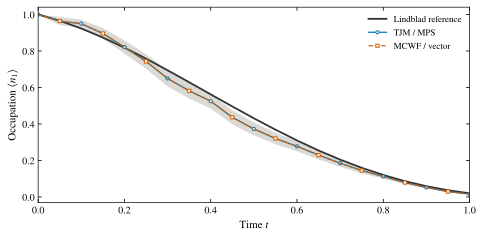

In [4]:
fig, ax = plt.subplots(figsize=(6.6, 3.2))
reference = (1 - results["density_matrix"].expectation_values[0]) / 2
ax.plot(times, reference, color="0.2", label="Lindblad reference")
for representation, color, marker, style, offset, label in (
    ("mps", "#0072B2", "o", "-", 0, "TJM / MPS"),
    ("vector", "#D55E00", "s", "--", 1, "MCWF / vector"),
):
    result = results[representation]
    mean = (1 - result.expectation_values[0]) / 2
    samples = (1 - result.trajectories[0]) / 2
    standard_error = samples.std(axis=0, ddof=1) / np.sqrt(samples.shape[0])
    ax.fill_between(times, mean - standard_error, mean + standard_error, color=color, alpha=0.14, linewidth=0)
    ax.plot(times, mean, color=color, marker=marker, linestyle=style,
            markevery=(offset, 2), markersize=3.2, markerfacecolor="white",
            linewidth=1.2, label=label)
ax.set(xlabel=r"Time $t$", ylabel=r"Occupation $\langle n_1\rangle$", xlim=(0, 1), ylim=(-0.03, 1.04))
ax.legend(loc="upper right")
plt.show()

The lines show excitation transport combined with loss. Shaded bands give one
estimated standard error of the trajectory means at each time; they are not
bounds on the numerical error or simultaneous confidence bands. Sixty-four
trajectories illustrate statistical variation, not a converged benchmark or a
runtime comparison. The shared seed can correlate the two trajectory estimates.
Lindblad supplies a deterministic numerical reference, not an error-free
solution.

## Check accuracy and supported workflows

For noisy MPS and vector results, increase `num_traj` to test sampling error,
then reduce `dt` to check time resolution. For MPS, also increase `max_bond_dim`
and reduce `svd_threshold` to check compression. A product initial state can
become entangled during evolution; its initial simplicity does not make the
later MPS approximation exact. Use {doc}`simulation_parameters` for presets and
solver-specific controls.

| Workflow or input                        | Supported representations                                                                           |
| ---------------------------------------- | --------------------------------------------------------------------------------------------------- |
| Static-Hamiltonian analog evolution      | MPS, vector, and density matrix; noise must meet the restrictions in {doc}`realistic_noise_models`. |
| Circuits and analog-digital programs     | MPS.                                                                                                |
| Mixed initial state                      | Density matrix.                                                                                     |
| Bitstring-probability observables        | MPS with qubits at every site.                                                                      |
| Entropy and Schmidt-spectrum observables | MPS; noisy results describe pure trajectories, not the spectrum of a mixed density matrix.          |
| Piecewise Hamiltonian                    | MPS with TDVP; see {doc}`hamiltonians`.                                                             |
| Unitary `list[State]` ensemble           | MPS; see {doc}`ensemble_evolution`.                                                                 |

Noisy MPS, vector, and circuit runs do not return one final pure state for the
trajectory ensemble. Noisy density-matrix evolution can retain its final mixed
state with `get_state=True`.

Choose MPS when the required bond dimensions remain affordable, vector when a
full pure state fits and provides a useful reference, and density matrix when
you need a small-system ensemble average or mixed-state evolution. Check
convergence for the quantities you intend to report before scaling up.